#**Import Libraries**

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#**Custom Functions**

In [ ]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)


    # For each metric
    for i, metric_name in enumerate(metrics):
        # Get the axis for the current metric
        if len(metrics)==1:
            ax = axes
        else:
            ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()
    return fig, axes

#**Get Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load data from your path
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week18/nba_logreg.csv',index_col = 'name')
df.head()

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
name,,,,,,,,,,,,,,,,,,,,
Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


#**Clean Data**

In [ ]:
# Check for null values
df.isna().sum().sum()

np.int64(11)

In [ ]:
# Drop missings
df.dropna(inplace = True)

#**Define X and y and Train Test and Validation Split**

In [ ]:
# Define X and y
target = 'target_5yrs'
X = df.drop(columns = target)
y = df[target]
# Train test_Val split
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size = .3, random_state=42)

In [ ]:
# Split the X_test_val into test and val data
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size = .5, random_state=42)

#**Scale Data**

In [ ]:
# Scale our data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

#**Create Basic Model**

In [ ]:
# Step 1: Define our network structure
# Save the number of features we have as our input shape
input_shape = X_train.shape[1]
input_shape

19

In [ ]:
# Without dropout
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
              metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision'),
                        ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591 (2.31 KB)

 Trainable params: 591 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
history = model.fit(X_train, y_train,
                    validation_data= (X_val, y_val),
                    epochs=50)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3699 - loss: 0.7973 - precision: 0.4573 - recall: 0.1311 - val_accuracy: 0.3920 - val_loss: 0.7383 - val_precision: 0.4590 - val_recall: 0.2414
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5032 - loss: 0.7040 - precision: 0.6440 - recall: 0.4301 - val_accuracy: 0.6281 - val_loss: 0.6672 - val_precision: 0.6667 - val_recall: 0.7241
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6559 - loss: 0.6449 - precision: 0.6938 - recall: 0.7885 - val_accuracy: 0.6985 - val_loss: 0.6147 - val_precision: 0.6944 - val_recall: 0.8621
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6839 - loss: 0.6075 - precision: 0.7112 - recall: 0.8182 - val_accuracy: 0.6935 - val_loss: 0.5810 - val_precision: 0.6950 - val_recall: 0.8448
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7011 - loss: 0.5906 - precision: 0.7255 - recall: 0.8269 - val_accuracy: 0.6985 - val_loss: 0.5709 

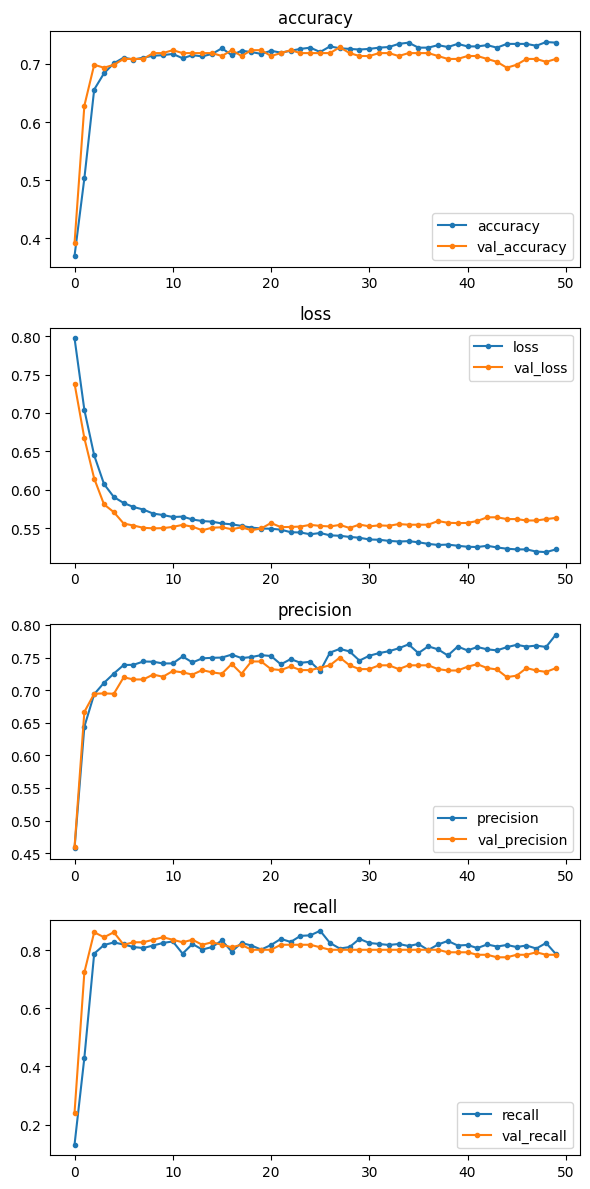

In [ ]:
# Visualize the results
plot_history(history, marker='.');

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7550 - loss: 0.5225 - precision: 0.8201 - recall: 0.8261


{'accuracy': 0.7549999952316284,
 'loss': 0.5224912166595459,
 'precision': 0.8201438784599304,
 'recall': 0.8260869383811951}

#**Include a Dropout Layer**

In [ ]:
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])
history = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4753 - loss: 0.8622 - precision: 0.5986 - recall: 0.4458 - val_accuracy: 0.4623 - val_loss: 0.7147 - val_precision: 0.5455 - val_recall: 0.4655
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5065 - loss: 0.7368 - precision: 0.6170 - recall: 0.5210 - val_accuracy: 0.6533 - val_loss: 0.6384 - val_precision: 0.6942 - val_recall: 0.7241
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5688 - loss: 0.6752 - precision: 0.6508 - recall: 0.6451 - val_accuracy: 0.7035 - val_loss: 0.6109 - val_precision: 0.7209 - val_recall: 0.8017
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6065 - loss: 0.6502 - precision: 0.6635 - recall: 0.7308 - val_accuracy: 0.6985 - val_loss: 0.5943 - val_precision: 0.7295 - val_recall: 0.7672
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6118 - loss: 0.6331 - precision: 0.6688 - recall: 0.7308 - val_accuracy: 0.6834 - val_loss: 0.5863 - val_precision

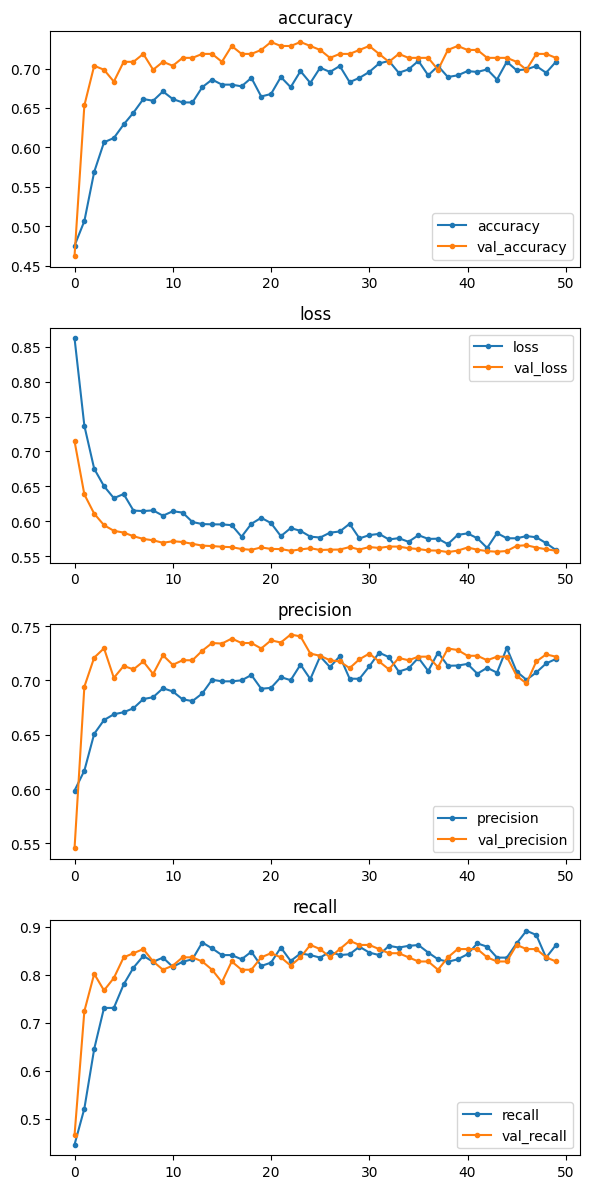

In [ ]:
# Visualize the results
plot_history(history, marker='.');

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7300 - loss: 0.5440 - precision: 0.8088 - recall: 0.7971


{'accuracy': 0.7300000190734863,
 'loss': 0.5440297722816467,
 'precision': 0.8088235259056091,
 'recall': 0.7971014380455017}

#**Early Stopping in Keras**


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# With early stopping
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Instantiate EarlyStopping
early_stopping = EarlyStopping(patience = 5)

In [ ]:
# Fit the model with the early stopping callback
history = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs=100,
                    callbacks = [early_stopping])

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5731 - loss: 0.6601 - precision: 0.6144 - recall: 0.8217 - val_accuracy: 0.6281 - val_loss: 0.6295 - val_precision: 0.6313 - val_recall: 0.8707
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6247 - loss: 0.6315 - precision: 0.6509 - recall: 0.8409 - val_accuracy: 0.6935 - val_loss: 0.6049 - val_precision: 0.6871 - val_recall: 0.8707
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6409 - loss: 0.6191 - precision: 0.6667 - recall: 0.8322 - val_accuracy: 0.6985 - val_loss: 0.5964 - val_precision: 0.6944 - val_recall: 0.8621
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6634 - loss: 0.6099 - precision: 0.6953 - recall: 0.8059 - val_accuracy: 0.7136 - val_loss: 0.5831 - val_precision: 0.7360 - val_recall: 0.7931
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6828 - loss: 0.6031 - precision: 0.7230 - recall: 0.7850 - val_accuracy: 0.7085 - val_loss: 0.5748

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7100 - loss: 0.5400 - precision: 0.7857 - recall: 0.7971 


{'accuracy': 0.7099999785423279,
 'loss': 0.5400032997131348,
 'precision': 0.7857142686843872,
 'recall': 0.7971014380455017}

#**Using Dropout layer and Early Stopping**

In [ ]:
# With dropout and early stopping
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dropout(.5))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Instantiate early stopping
early_stopping = EarlyStopping(patience = 5)

In [ ]:
# Fit the model with the early stopping callback
history = model.fit(X_train, y_train,
                    validation_data = (X_test, y_test),
                    epochs=100,
                    callbacks = [early_stopping])

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5602 - loss: 0.7350 - precision: 0.6546 - recall: 0.6031 - val_accuracy: 0.6550 - val_loss: 0.6553 - val_precision: 0.7379 - val_recall: 0.7754
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5903 - loss: 0.6770 - precision: 0.6733 - recall: 0.6486 - val_accuracy: 0.6350 - val_loss: 0.6336 - val_precision: 0.7338 - val_recall: 0.7391
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6247 - loss: 0.6496 - precision: 0.6837 - recall: 0.7255 - val_accuracy: 0.6550 - val_loss: 0.6222 - val_precision: 0.7482 - val_recall: 0.7536
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6344 - loss: 0.6360 - precision: 0.7057 - recall: 0.6958 - val_accuracy: 0.6700 - val_loss: 0.6173 - val_precision: 0.7727 - val_recall: 0.7391
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6462 - loss: 0.6289 - precision: 0.6982 - recall: 0.7483 - val_accuracy: 0.6750 - val_loss: 0.6082

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7150 - loss: 0.5506 - precision: 0.7914 - recall: 0.7971 


{'accuracy': 0.7149999737739563,
 'loss': 0.5505774021148682,
 'precision': 0.7913669347763062,
 'recall': 0.7971014380455017}

# 📊 COMPARISON: Regularization Methods
# =====================================


# 📌 RESULTS TABLE

| Model | Accuracy | Loss | Precision | Recall |
|-------|----------|------|-----------|--------|
| **Base (No Reg)** | 75.5% | 0.522 | 82.0% | 82.6% |
| **Dropout (0.5)** | 73.0% 🔻 | 0.544 🔺 | 80.9% 🔻 | 79.7% 🔻 |
| **Early Stopping** | 71.0% 🔻 | 0.540 🔺 | 78.6% 🔻 | 79.7% 🔻 |
| **Dropout + Early** | 71.5% 🔻 | 0.551 🔺 | 79.1% 🔻 | 79.7% 🔻 |


# 📈 ANALYSIS
# ==========

# ✅ BEST MODEL: Base (No Regularization)
#    - Highest Accuracy: 75.5% 👑
#    - Highest Precision: 82.0% 👑
#    - Highest Recall: 82.6% 👑
#    - Lowest Loss: 0.522 👑

# ❌ All regularization methods decreased performance
#    - Dropout alone: Accuracy ↓ 2.5%
#    - Early Stopping alone: Accuracy ↓ 4.5%
#    - Combined: Accuracy ↓ 4.0%


# 💡 CONCLUSION
# ============
# Model was NOT overfitting → No need for regularization
# Base model is already optimal for this dataset

# 🎯 FINAL VERDICT
# ================
# Use Base Model without Dropout or Early Stopping ✅

# 📝 Note
# Regularization helps ONLY when model overfits
# Your base model had good val_loss → no overfitting